# Vision Transformer (ViT) Implementation Notebook

This notebook implements a Vision Transformer model for image classification on either MNIST or CIFAR-10 datasets. The implementation follows the architecture described in the original "An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale" paper by Dosovitskiy et al. with specific adjusting to hyperparameters and other architectural components to suit smaller datasets.

## 1. Introduction to Vision Transformers

Vision Transformers (ViT) represent a significant shift from convolutional neural networks (CNNs) in computer vision. Rather than using convolutional layers, ViTs split images into fixed-size patches, linearly embed each patch, add position embeddings, and feed the resulting sequence of vectors to a standard Transformer encoder.

Key advantages of Vision Transformers:
- They can capture global dependencies in the image directly
- They scale better with dataset size and model size
- They transfer well to downstream tasks

Let's start by importing the necessary libraries and setting up our configuration.

You can choose Between (cifar-10) and (MNIST) by only changing DATASET_CHOICE variable.

In [14]:
import torch
import pandas as pd
from torch import nn
from torch import optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST, CIFAR10
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import random
import timeit
from tqdm import tqdm
import os
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from typing import Dict, List
import sys
import argparse

# Single configuration point to control the dataset choice
DATASET_CHOICE = "cifar10"  # Change only this word to "mnist" or "cifar10"

## 2. Configuration Setup

The `Config` class organizes all hyperparameters and settings in one place. This makes it easy to track experiment configurations and modify settings systematically.

In [15]:
class Config:
    # General
    RANDOM_SEED = 42
    # Data
    BATCH_SIZE = 256
    NUM_CLASSES = 10
    DATASET = DATASET_CHOICE  # Use the single configuration point

    # Dataset specific configs - will be set based on dataset choice
    IMG_SIZE = None  # Will be set to 28 for MNIST or 32 for CIFAR10
    IN_CHANNELS = None  # Will be set to 1 for MNIST or 3 for CIFAR10

    # Model
    PATCH_SIZE = 4
    EMBED_DIM = 256
    NUM_PATCHES = None  # Will be calculated based on IMG_SIZE and PATCH_SIZE
    NUM_HEADS = 8
    HIDDEN_DIM = 1024
    NUM_ENCODERS = 4
    DROPOUT = 0.1
    ACTIVATION = "gelu"
    # Training
    EPOCHS = 60
    LEARNING_RATE = 1e-3
    WEIGHT_DECAY = 1e-4
    ADAM_BETAS = (0.9, 0.999)
    GRAD_CLIP_VAL = 1.0
    LR_MIN = 1e-5

    # Data paths
    DATA_PATH = './data'

    def update_for_dataset(self, dataset_name):
        self.DATASET = dataset_name.lower()

        if self.DATASET == "mnist":
            self.IMG_SIZE = 28
            self.IN_CHANNELS = 1
        elif self.DATASET == "cifar10":
            self.IMG_SIZE = 32
            self.IN_CHANNELS = 3
        else:
            raise ValueError(f"Unsupported dataset: {dataset_name}")

        self.NUM_PATCHES = (self.IMG_SIZE // self.PATCH_SIZE) ** 2

## 3. Command Line Argument Parsing
The parse_args() function intelligently detects whether the code is running in a Jupyter notebook or as a standalone script. In a notebook, it uses default arguments from a predefined Args class, while in a script, it processes command-line inputs via argparse, allowing users to specify the dataset (e.g., --dataset cifar10). A global Config object (cfg) centralizes settings, ensuring consistency.
To guarantee reproducibility, set_seeds() fixes random seeds across Python, NumPy, and PyTorch, including CUDA operations if a GPU is available. The device (CUDA/CPU) is automatically selected for optimal performance. This approach ensures reliable execution across different environments while maintaining flexibility in configuration.

In [16]:
# Modified parse_args to work in both script and notebook environments
def parse_args():
    # Check if running in notebook or as script
    try:
        if 'ipykernel' in sys.modules:
            # We're in a notebook, return default arguments
            class Args:
                def __init__(self):
                    self.dataset = DATASET_CHOICE  # Use the single configuration point
            return Args()
    except:
        pass

    # We're running as a script, use argparse
    parser = argparse.ArgumentParser(description='Train ViT on MNIST or CIFAR10')
    parser.add_argument('--dataset', type=str, default=DATASET_CHOICE, choices=['mnist', 'cifar10'],
                        help='Dataset to use (mnist or cifar10)')
    return parser.parse_args()

# Set config
cfg = Config()

# Set random seeds for reproducibility
def set_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = "cuda" if torch.cuda.is_available() else "cpu"

## 4. Patch Embedding Module

The Patch Embedding module is the first component of the Vision Transformer. It:
1. Divides the image into fixed-size non-overlapping patches
2. Flattens each patch into a vector
3. Projects these vectors to a desired embedding dimension
4. Adds a learnable classification token (CLS token)
5. Adds learnable position embeddings to retain spatial information

In [17]:
class PatchEmbedding(nn.Module):
    def __init__(self, embed_dim, patch_size, num_patches, dropout, in_channels):
        super().__init__()
        self.patcher = nn.Sequential(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=embed_dim,
                kernel_size=patch_size,
                stride=patch_size,
            ),
            nn.Flatten(2))
        # Initialize with normal distribution with lower std for better training stability
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02,
                             requires_grad=True)

        # Calculate the actual number of patches based on image dimensions
        # For CIFAR-10 with 32x32 images and patch_size=4, this should be 8x8=64 patches
        # Plus 1 for the CLS token = 65 position embeddings

        # For MNIST with 28x28 images and patch_size=4, this should be 7x7=49 patches
        # Plus 1 for the CLS token = 50 position embeddings

        actual_num_patches = (cfg.IMG_SIZE // patch_size) ** 2

        self.position_embeddings = nn.Parameter(
            torch.randn(1, actual_num_patches+1, embed_dim) * 0.02,
            requires_grad=True
        )
        self.dropout = nn.Dropout(p=dropout)
        # Added layer norm before feeding to transformer
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        batch_size = x.shape[0]
        # Convert to correct shape: [batch_size, 1, embed_dim]
        cls_token = self.cls_token.expand(batch_size, -1, -1)

        # Get patches and transpose to [batch_size, num_patches, embed_dim]
        x = self.patcher(x).permute(0, 2, 1)

        # Concatenate CLS token
        x = torch.cat([cls_token, x], dim=1)

        # Add position embeddings
        x = self.position_embeddings + x
        x = self.dropout(x)
        x = self.norm(x)
        return x

## 5. MLP and Transformer Components

These modules implement the core components of the Transformer architecture. The Transformer consists of alternating blocks of Multi-Head Self-Attention (MSA) and MLP blocks, with Layer Normalization and residual connections.

### MLPHead Class

The MLPHead class implements a multi-layer perceptron head for the Vision Transformer. It consists of:
- Two fully connected layers with a GELU activation in between
- Dropout layers for regularization
- A flexible architecture that can be used for both intermediate and final classification layers

In [18]:
class MLPHead(nn.Module):
    def __init__(self, in_features, hidden_features, out_features, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.dropout(x)
        return x

In [19]:
class MSABlock(nn.Module):
    def __init__(self, embedding_dim, num_heads, attn_dropout):
        super().__init__()
        self.multihead_attn = nn.MultiheadAttention(embed_dim=embedding_dim,
                                                   num_heads=num_heads,
                                                   dropout=attn_dropout,
                                                   batch_first=True)

    def forward(self, x):
        attention_result = self.multihead_attn(
            query=x,
            key=x,
            value=x,
            need_weights=False
        )[0]
        return attention_result

class MLPBlock(nn.Module):
    def __init__(self, embedding_dim, mlp_size, dropout):
        super().__init__()
        self.mlp = nn.Sequential(
        nn.Linear(in_features=embedding_dim, out_features=mlp_size),
        nn.GELU(),
        nn.Dropout(p=dropout),
        nn.Linear(in_features=mlp_size, out_features=embedding_dim),
        nn.Dropout(p=dropout)
        )

    def forward(self, x):
        x_mlp = self.mlp(x)
        return x_mlp


class TransformerEncoder(nn.Module):
    def __init__(self, embedding_dim, num_heads, mlp_size, mlp_dropout, attn_dropout):
        super().__init__()
        self.attn_norm = nn.LayerNorm(normalized_shape=embedding_dim)
        self.mlp_norm = nn.LayerNorm(normalized_shape=embedding_dim)

        self.msa_block = MSABlock(embedding_dim=embedding_dim,
                                                 num_heads=num_heads,
                                                 attn_dropout=attn_dropout)
        self.mlp_block = MLPBlock(embedding_dim=embedding_dim,
                               mlp_size=mlp_size,
                               dropout=mlp_dropout)

    def forward(self, x):
        # Apply norm before attention
        x_norm = self.attn_norm(x)
        x = self.msa_block(x_norm) + x
        # Apply norm before MLP
        x_norm = self.mlp_norm(x)
        x = self.mlp_block(x_norm) + x

        return x

## 6. Vision Transformer (ViT) Model

Now we implement the complete Vision Transformer (ViT) model. This combines all the components:
1. Patch Embedding
2. Transformer Encoder blocks (multiple layers)
3. MLP Head for classification

The model follows the architecture from the original ViT paper with some enhancements for improved training stability.

In [20]:
# Modified ViT model
class ViT(nn.Module):
    def __init__(self, num_patches, img_size, num_classes, patch_size, embed_dim, num_encoders, num_heads, hidden_dim, dropout, activation, in_channels):
        super().__init__()
        self.embeddings_block = PatchEmbedding(embed_dim, patch_size, num_patches, dropout, in_channels)

        # Create stack of transformer encoder blocks
        self.encoder_blocks = nn.ModuleList([
            TransformerEncoder(
                embedding_dim=embed_dim,
                num_heads=num_heads,
                mlp_size=hidden_dim,
                mlp_dropout=dropout,
                attn_dropout=dropout
            ) for _ in range(num_encoders)
        ])

        # Enhanced MLP head with multiple layers
        self.mlp_head = nn.Sequential(
            MLPHead(
                in_features=embed_dim,
                hidden_features=hidden_dim//2,
                out_features=num_classes,
                dropout=dropout
            )
        )

    def forward(self, x):
        x = self.embeddings_block(x)

        # Pass through transformer encoder blocks
        for encoder_block in self.encoder_blocks:
            x = encoder_block(x)

        # Apply MLP on the CLS token only
        x = self.mlp_head(x[:, 0, :])
        return x

## 7. Model Analysis Functions

These functions help us analyze and understand the model's complexity, parameter distribution, and architecture. This information is valuable for model debugging, optimization, and reporting.

In [21]:
def count_parameters(model):
    """
    Count the total number of trainable parameters in the model.

    Args:
        model: PyTorch model

    Returns:
        total_params: Total number of trainable parameters
        param_size: Estimated model size in MB
    """
    # Count parameters that require gradients
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # Estimate model size (4 bytes per float parameter)
    param_size = total_params * 4 / (1024 * 1024)

    return total_params, param_size

def print_model_summary(model):
    """
    Print a detailed summary of the model architecture and parameter count per layer.

    Args:
        model: PyTorch model
    """
    print("\nModel Architecture Summary:")
    print("=" * 100)
    print(f"{'Layer':<40} {'Output Shape':<25} {'Param #':<10}")
    print("-" * 100)

    total_params = 0
    for name, module in model.named_children():
        params = sum(p.numel() for p in module.parameters() if p.requires_grad)
        total_params += params

        if isinstance(module, nn.Sequential):
            for sub_name, sub_module in module.named_children():
                sub_params = sum(p.numel() for p in sub_module.parameters() if p.requires_grad)
                print(f"{name}.{sub_name:<35} {'-':<25} {sub_params:<10,}")
        else:
            print(f"{name:<40} {'-':<25} {params:<10,}")

    print("-" * 100)
    print(f"Total trainable parameters: {total_params:,}")
    print(f"Estimated model size: {total_params * 4 / (1024 * 1024):.2f} MB")
    print("=" * 100)

def analyze_model_complexity(model, input_size):
    """
    Analyze model complexity by calculating:
    1. Total parameters
    2. Parameter distribution by layer
    3. Theoretical FLOPs for a forward pass

    Args:
        model: PyTorch model
        input_size: Tuple representing input shape (B, C, H, W)
    """
    # Get parameter counts
    total_params, model_size_mb = count_parameters(model)

    # Print model complexity metrics
    print("\nModel Complexity Analysis:")
    print("-" * 80)
    print(f"Total Parameters: {total_params:,}")
    print(f"Model Size: {model_size_mb:.2f} MB")

    # Calculate parameter distribution by layer type
    layer_type_params = {}
    for name, module in model.named_modules():
        if len(list(module.children())) == 0:  # If it's a leaf module
            layer_type = module.__class__.__name__
            params = sum(p.numel() for p in module.parameters() if p.requires_grad)
            if params > 0:
                if layer_type not in layer_type_params:
                    layer_type_params[layer_type] = 0
                layer_type_params[layer_type] += params

    print("\nParameter Distribution by Layer Type:")
    print("-" * 80)
    for layer_type, params in sorted(layer_type_params.items(), key=lambda x: x[1], reverse=True):
        percentage = (params / total_params) * 100
        print(f"{layer_type:<20}: {params:,} parameters ({percentage:.2f}%)")

    print("-" * 80)

## 8. Training and Testing Functions

These functions implement the core training and evaluation loops. The `train` function updates the model with a batch of data, while the `test` function evaluates the model's performance on a dataset.

In [22]:
# Implement the required train function
def train(model: nn.Module,
          loss_fn: nn.modules.loss._Loss,
          optimizer: torch.optim.Optimizer,
          train_loader: torch.utils.data.DataLoader,
          epoch: int=0) -> List:
    model.train()
    train_loss = []

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()

        # Add gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP_VAL)

        optimizer.step()
        train_loss.append(loss.item())
        if batch_idx % max(1, len(train_loader) // 8) == 0:
            print(f'Epoch {epoch}: [{batch_idx*len(images)}/{len(train_loader.dataset)}] Loss: {loss.item():.3f}')

    assert len(train_loss) == len(train_loader)
    return train_loss

# Implement the required test function
def test(model: nn.Module,
         loss_fn: nn.modules.loss._Loss,
         test_loader: torch.utils.data.DataLoader,
         epoch: int=0) -> Dict:
    model.eval()
    test_loss = 0
    correct = 0
    total_num = len(test_loader.dataset)
    predictions = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            test_loss += loss_fn(outputs, labels).item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()
            predictions.append(predicted)

    all_predictions = torch.cat(predictions)
    test_loss /= total_num
    accuracy = correct / total_num

    test_stat = {
        "loss": test_loss,
        "accuracy": accuracy,
        "prediction": all_predictions.cpu()
    }
    print(f"Test result on epoch {epoch}: total sample: {total_num}, Avg loss: {test_stat['loss']:.3f}, Acc: {100*test_stat['accuracy']:.3f}%")

    assert "loss" and "accuracy" and "prediction" in test_stat.keys()
    assert len(test_stat["prediction"]) == len(test_loader.dataset)
    assert isinstance(test_stat["prediction"], torch.Tensor)
    return test_stat

## 9. Data Preprocessing and Loading

These functions handle dataset loading, transformation, and preparation. We use different transformations for training and validation/testing to incorporate data augmentation during training.

In [23]:
# Get dataset-specific transforms
def get_transforms(dataset_name):
    if dataset_name == 'mnist':
        train_transform = transforms.Compose([
            transforms.RandomRotation(15),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
            transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
        ])

        val_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])
    elif dataset_name == 'cifar10':
        train_transform = transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
            transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
        ])

        val_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])
    else:
        raise ValueError(f"Unsupported dataset: {dataset_name}")

    return train_transform, val_transform

def get_datasets(dataset_name, train_transform, val_transform):
    if dataset_name == 'mnist':
        train_dataset = MNIST(root=cfg.DATA_PATH, train=True, download=True, transform=train_transform)
        test_dataset = MNIST(root=cfg.DATA_PATH, train=False, download=True, transform=val_transform)
        class_names = [str(i) for i in range(10)]
        val_dataset = MNIST(root=cfg.DATA_PATH, train=False, download=True, transform=val_transform)

    elif dataset_name == 'cifar10':
        train_dataset = CIFAR10(root=cfg.DATA_PATH, train=True, download=True, transform=train_transform)
        test_dataset = CIFAR10(root=cfg.DATA_PATH, train=False, download=True, transform=val_transform)
        class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
        val_dataset = CIFAR10(root=cfg.DATA_PATH, train=False, download=True, transform=val_transform)

    else:
        raise ValueError(f"Unsupported dataset: {dataset_name}")

    print(f"Training set size: {len(train_dataset)}")
    print(f"Validation set size: {len(val_dataset)}")
    print(f"Test set size: {len(test_dataset)}")

    return train_dataset, val_dataset, test_dataset, class_names

## 10. Visualization Function

This function visualizes model predictions on test samples, which helps with qualitative model evaluation.

In [24]:
# Function to visualize results based on dataset
def visualize_results(test_dataset, model, class_names, dataset_name):
    plt.figure(figsize=(12, 8))
    sample_indices = random.sample(range(len(test_dataset)), 6)

    for i, idx in enumerate(sample_indices):
        img, label = test_dataset[idx]
        # Direct prediction without test time augmentation
        with torch.no_grad():
            img_tensor = img.unsqueeze(0).to(device)
            outputs = model(img_tensor)
            _, pred = torch.max(outputs, 1)
            pred = pred.item()

        plt.subplot(2, 3, i+1)

        # Plot differently based on dataset
        if dataset_name == 'mnist':
            plt.imshow(img.squeeze(), cmap="gray")
        else:  # CIFAR10 - convert back from normalized
            img_display = img.permute(1, 2, 0).numpy() * 0.5 + 0.5
            img_display = np.clip(img_display, 0, 1)
            plt.imshow(img_display)

        plt.title(f"True: {class_names[label]}, Pred: {class_names[pred]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

## 11. Main Function

The main function orchestrates the entire training and evaluation pipeline:

1. **Setup and Configuration**: Parses arguments, sets random seeds, and configures the environment
2. **DataLoaders and Model Initialization**: Creates data loaders and initializes the Vision Transformer model
3. **Model Analysis**: Provides insights into parameter distribution and computational requirements
4. **Optimizer and Learning Rate Scheduler**: Sets up optimization components including AdamW optimizer and cosine annealing schedule
5. **Training Loop**: Runs the training and validation process
6. **Visualization and Evaluation**: Displays training history and model predictions

This comprehensive function ensures all components work together seamlessly for end-to-end model training and evaluation.

In [25]:
# Main execution block
def main():
    # Parse arguments
    args = parse_args()

    # Update config for the selected dataset
    cfg.update_for_dataset(args.dataset)

    # Set random seeds
    set_seeds(cfg.RANDOM_SEED)

    print(f"Training ViT on {cfg.DATASET} dataset")
    print(f"Image size: {cfg.IMG_SIZE}x{cfg.IMG_SIZE}, Channels: {cfg.IN_CHANNELS}")
    print(f"Device: {device}")

    # Get transforms and datasets
    train_transform, val_transform = get_transforms(cfg.DATASET)
    train_dataset, val_dataset, test_dataset, class_names = get_datasets(
        cfg.DATASET, train_transform, val_transform
    )
    # Create dataloaders
    train_dataloader = DataLoader(
        dataset=train_dataset,
        batch_size=cfg.BATCH_SIZE,
        shuffle=True
    )
    val_dataloader = DataLoader(
        dataset=val_dataset,
        batch_size=cfg.BATCH_SIZE,
        shuffle=False
    )
    test_dataloader = DataLoader(
        dataset=test_dataset,
        batch_size=cfg.BATCH_SIZE,
        shuffle=False
    )

    # Initialize model
    model = ViT(
        cfg.NUM_PATCHES,
        cfg.IMG_SIZE,
        cfg.NUM_CLASSES,
        cfg.PATCH_SIZE,
        cfg.EMBED_DIM,
        cfg.NUM_ENCODERS,
        cfg.NUM_HEADS,
        cfg.HIDDEN_DIM,
        cfg.DROPOUT,
        cfg.ACTIVATION,
        cfg.IN_CHANNELS
    ).to(device)
    # Calculate and display model parameters
    total_params, model_size_mb = count_parameters(model)
    print(f"\nTotal trainable parameters: {total_params:,}")
    print(f"Estimated model size: {model_size_mb:.2f} MB")

    # Print detailed model summary
    print_model_summary(model)

    # More detailed analysis of model complexity
    if cfg.DATASET == "mnist":
        sample_input_size = (1, 1, 28, 28)
    else:  # CIFAR10
        sample_input_size = (1, 3, 32, 32)

    analyze_model_complexity(model, sample_input_size)
    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        model.parameters(),
        lr=cfg.LEARNING_RATE,
        betas=cfg.ADAM_BETAS,
        weight_decay=cfg.WEIGHT_DECAY
    )

    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=cfg.EPOCHS,
        eta_min=cfg.LR_MIN
    )

    # Training history
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_accuracy': []
    }
    # Training loop with the specified train/test functions
    start = timeit.default_timer()
    for epoch in tqdm(range(cfg.EPOCHS), position=0, leave=True):
        # Train for one epoch
        train_loss = train(model, criterion, optimizer, train_dataloader, epoch)

        # Test on validation set
        val_stats = test(model, criterion, val_dataloader, epoch)

        # Update history
        history['train_loss'].append(np.mean(train_loss))
        history['val_loss'].append(val_stats['loss'])
        history['val_accuracy'].append(val_stats['accuracy'])

        # Update scheduler
        scheduler.step()

    stop = timeit.default_timer()
    print(f"Training Time: {stop-start:.2f}s")
    # Plot training history
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()


    # Visualize some predictions
    visualize_results(test_dataset, model, class_names, cfg.DATASET)

## 12. Script Execution

This final cell allows the notebook to be executed directly or run as a script.

Training ViT on cifar10 dataset
Image size: 32x32, Channels: 3
Device: cuda
Training set size: 50000
Validation set size: 10000
Test set size: 10000

Total trainable parameters: 3,325,706
Estimated model size: 12.69 MB

Model Architecture Summary:
Layer                                    Output Shape              Param #   
----------------------------------------------------------------------------------------------------
embeddings_block                         -                         29,952    
encoder_blocks                           -                         3,159,040 
mlp_head.0                                   -                         136,714   
----------------------------------------------------------------------------------------------------
Total trainable parameters: 3,325,706
Estimated model size: 12.69 MB

Model Complexity Analysis:
--------------------------------------------------------------------------------
Total Parameters: 3,325,706
Model Size: 12.69 MB

Parame

  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 0: [0/50000] Loss: 2.354
Epoch 0: [6144/50000] Loss: 2.150
Epoch 0: [12288/50000] Loss: 2.004
Epoch 0: [18432/50000] Loss: 1.903
Epoch 0: [24576/50000] Loss: 1.906
Epoch 0: [30720/50000] Loss: 1.722
Epoch 0: [36864/50000] Loss: 1.578
Epoch 0: [43008/50000] Loss: 1.654
Epoch 0: [49152/50000] Loss: 1.512


  2%|▏         | 1/60 [01:01<1:00:26, 61.46s/it]

Test result on epoch 0: total sample: 10000, Avg loss: 1.549, Acc: 44.010%
Epoch 1: [0/50000] Loss: 1.657
Epoch 1: [6144/50000] Loss: 1.542
Epoch 1: [12288/50000] Loss: 1.505
Epoch 1: [18432/50000] Loss: 1.589
Epoch 1: [24576/50000] Loss: 1.402
Epoch 1: [30720/50000] Loss: 1.384
Epoch 1: [36864/50000] Loss: 1.402
Epoch 1: [43008/50000] Loss: 1.469
Epoch 1: [49152/50000] Loss: 1.491


...

Test result on epoch 57: total sample: 10000, Avg loss: 0.549, Acc: 81.350%
Epoch 58: [0/50000] Loss: 0.771
Epoch 58: [6144/50000] Loss: 0.651
Epoch 58: [12288/50000] Loss: 0.660
Epoch 58: [18432/50000] Loss: 0.594
Epoch 58: [24576/50000] Loss: 0.555
Epoch 58: [30720/50000] Loss: 0.608
Epoch 58: [36864/50000] Loss: 0.637
Epoch 58: [43008/50000] Loss: 0.529
Epoch 58: [49152/50000] Loss: 0.561


 98%|█████████▊| 59/60 [1:00:29<01:01, 61.32s/it]

Test result on epoch 58: total sample: 10000, Avg loss: 0.544, Acc: 81.470%
Epoch 59: [0/50000] Loss: 0.545
Epoch 59: [6144/50000] Loss: 0.621
Epoch 59: [12288/50000] Loss: 0.541
Epoch 59: [18432/50000] Loss: 0.579
Epoch 59: [24576/50000] Loss: 0.636
Epoch 59: [30720/50000] Loss: 0.586
Epoch 59: [36864/50000] Loss: 0.479
Epoch 59: [43008/50000] Loss: 0.561
Epoch 59: [49152/50000] Loss: 0.630


100%|██████████| 60/60 [1:01:30<00:00, 61.51s/it]

Test result on epoch 59: total sample: 10000, Avg loss: 0.544, Acc: 81.670%
Training Time: 3690.57s


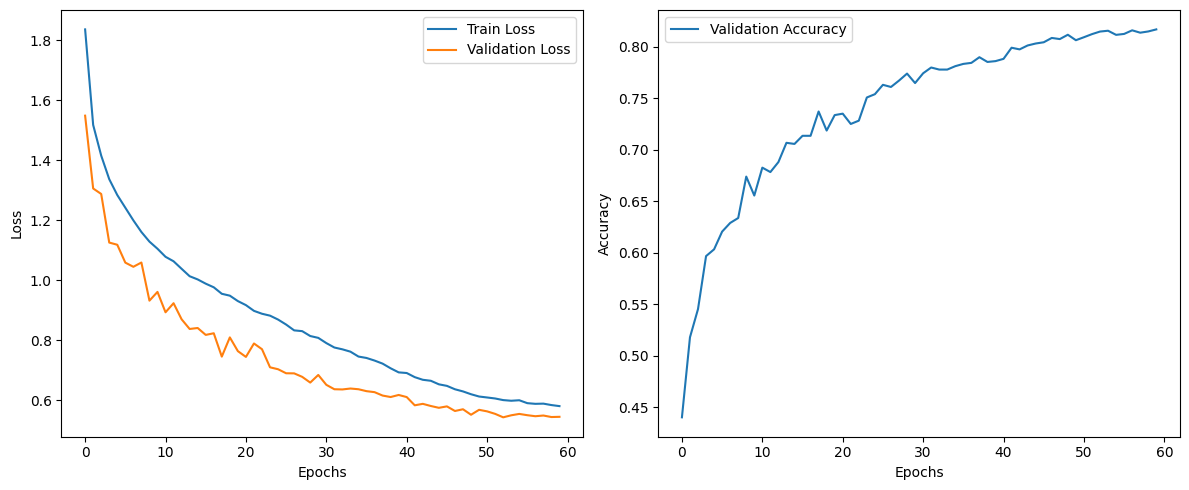

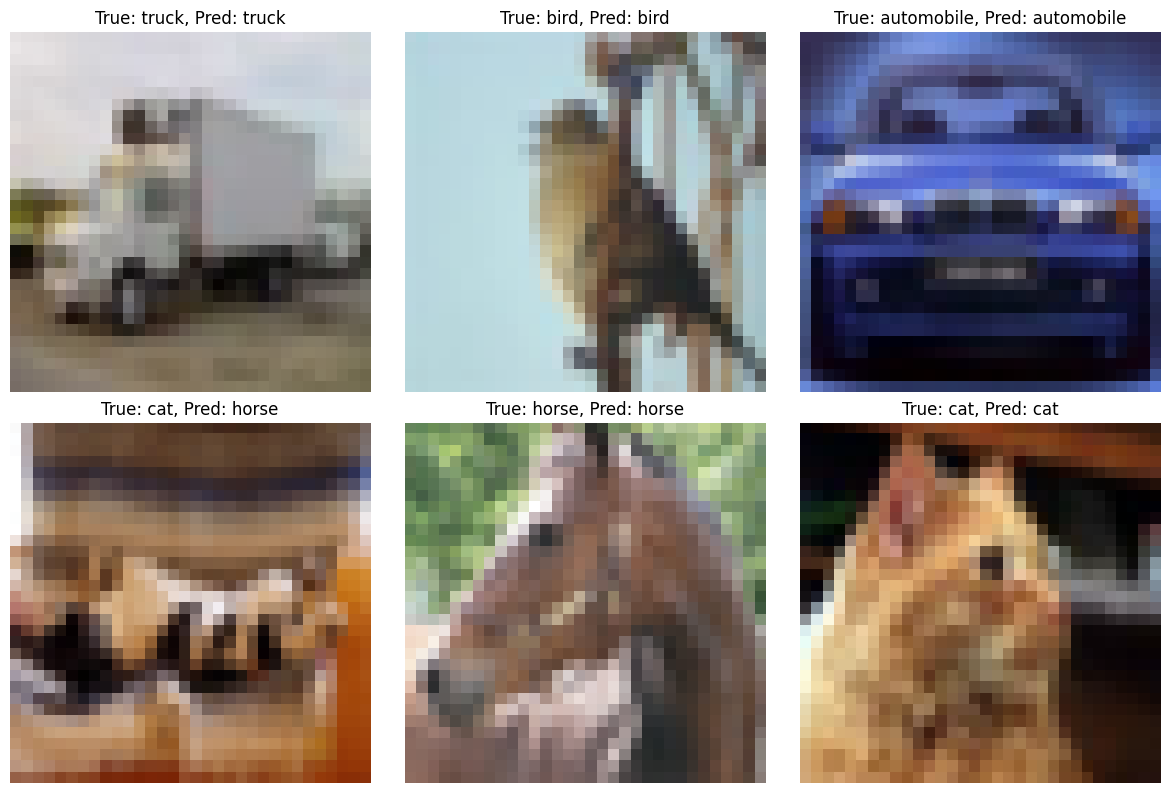

In [26]:
# For Jupyter notebooks, this enables direct execution without requiring command line arguments
if __name__ == "__main__":
    main()